# Data Integration

In [99]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [100]:
file_name = 'partpdf_1772778998739_partpdf_1763620928546_netflix_titles.xlsx'

all_sheets = pd.read_excel(file_name, sheet_name=None)

print(list(all_sheets.keys()))

['netflix_titles', 'netflix_titles_directors', 'netflix_titles_countries', 'netflix_titles_cast', 'netflix_titles_category']


In [101]:
# load each sheet
df_titles     = all_sheets['netflix_titles']
df_cast       = all_sheets['netflix_titles_cast']
df_directors  = all_sheets['netflix_titles_directors']
df_countries  = all_sheets['netflix_titles_countries']
df_categories = all_sheets['netflix_titles_category']

# combine multiple rows into one string per show_id
df_cast       = df_cast.groupby('show_id')['cast'].apply(', '.join).reset_index()
df_directors  = df_directors.groupby('show_id')['director'].apply(', '.join).reset_index()
df_countries  = df_countries.groupby('show_id')['country'].apply(', '.join).reset_index()
df_categories = df_categories.groupby('show_id')['listed_in'].apply(', '.join).reset_index()

# merge all into one master dataframe
df_master = df_titles.merge(df_cast,       on='show_id', how='left')
df_master = df_master.merge(df_directors,  on='show_id', how='left')
df_master = df_master.merge(df_countries,  on='show_id', how='left')
df_master = df_master.merge(df_categories, on='show_id', how='left')

print(df_master.shape)
df_master.info()

(6236, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6236 entries, 0 to 6235
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_minutes  4267 non-null   object 
 1   duration_seasons  1971 non-null   object 
 2   type              6235 non-null   object 
 3   title             6235 non-null   object 
 4   date_added        6223 non-null   object 
 5   release_year      6234 non-null   float64
 6   rating            6223 non-null   object 
 7   description       6233 non-null   object 
 8   show_id           6232 non-null   float64
 9   cast              5663 non-null   object 
 10  director          4263 non-null   object 
 11  country           5756 non-null   object 
 12  listed_in         6232 non-null   object 
dtypes: float64(2), object(11)
memory usage: 633.5+ KB


## Which Join Did I Use and Why?

I used a **LEFT JOIN** to merge all five sheets using `show_id` as the key.

Before merging, I grouped the cast, directors, countries and categories
sheets by `show_id` and combined multiple values into one comma-separated
string — so that the final dataframe has one row per title.

- `netflix_titles` is the main table — one row per title.
- The other 4 sheets are supplementary — extra info per title.
- LEFT JOIN keeps all titles from the main table, even if some
  titles have no cast, director, country or category data (those become NaN).
- INNER JOIN would drop titles with missing supplementary data — data loss.

LEFT JOIN with prior aggregation is the most appropriate choice.

# Data Cleaning and Preprocessing

In [102]:
df_master.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,director,country,listed_in
0,90,NaN,Movie,Norm of the North: King Sized Adventure,2019-09-09 00:00:00,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,"Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies"
1,94,NaN,Movie,Jandino: Whatever it Takes,2016-09-09 00:00:00,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,Jandino Asporaat,NaN,United Kingdom,Stand-Up Comedy
2,NaN,1,TV Show,Transformers Prime,2018-09-08 00:00:00,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,"Peter Cullen, Kevin Michael Richardson, Josh K...",NaN,United States,Kids' TV
3,NaN,1,TV Show,Transformers: Robots in Disguise,2018-09-08 00:00:00,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,"Will Friedle, Mitchell Whitfield, Ted McGinley...",NaN,United States,Kids' TV
4,99,NaN,Movie,#realityhigh,2017-09-08 00:00:00,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Fernando Lebrija,United States,Comedies


In [103]:
df_master.isnull().sum()

,0
duration_minutes,1969
duration_seasons,4265
type,1
title,1
date_added,13
release_year,2
rating,13
description,3
show_id,4
cast,573


In [104]:
# drop rows where critical columns are missing
df_master.dropna(subset=['type', 'title'], inplace=True)

# director — fill Unknown (TV Shows genuinely have no director)
df_master['director'].fillna('Unknown', inplace=True)

# cast — fill Unknown (some titles genuinely have no cast)
df_master['cast'].fillna('Unknown', inplace=True)

# country — fill Unknown (cannot fake a country)
df_master['country'].fillna('Unknown', inplace=True)

# rating — fill with mode (only 13 missing — safe)
df_master['rating'].fillna(df_master['rating'].mode()[0], inplace=True)

# listed_in — fill with mode (only 4 missing — safe)
df_master['listed_in'].fillna(df_master['listed_in'].mode()[0], inplace=True)

# release_year — fill with median
df_master['release_year'].fillna(df_master['release_year'].median(), inplace=True)

# description — fill with placeholder
df_master['description'].fillna('No description available', inplace=True)

print(df_master.shape)
df_master.isnull().sum()

(6235, 13)


,0
duration_minutes,1969
duration_seasons,4265
type,0
title,0
date_added,12
release_year,0
rating,0
description,0
show_id,3
cast,0


In [105]:
# convert date_added to proper datetime format
# errors='coerce' turns any bad values into NaT instead of crashing
df_master['date_added'] = pd.to_datetime(df_master['date_added'], errors='coerce')

# drop rows where date_added could not be parsed
df_master.dropna(subset=['date_added'], inplace=True)

# extract year_added for trend analysis
df_master['year_added'] = df_master['date_added'].dt.year

print(df_master.shape)
print(df_master[['date_added', 'year_added']].head(10))

(6222, 14)
  date_added  year_added
0 2019-09-09        2019
1 2016-09-09        2016
2 2018-09-08        2018
3 2018-09-08        2018
4 2017-09-08        2017
5 2017-09-08        2017
6 2017-09-08        2017
7 2017-09-08        2017
8 2017-09-08        2017
9 2017-09-08        2017


In [106]:
df_master.isnull().sum()

,0
duration_minutes,1959
duration_seasons,4263
type,0
title,0
date_added,0
release_year,0
rating,0
description,0
show_id,1
cast,0


In [107]:
# drop the 1 remaining row where show_id is missing
df_master.dropna(subset=['show_id'], inplace=True)

print(df_master.shape)
df_master.isnull().sum()

(6221, 14)


,0
duration_minutes,1959
duration_seasons,4262
type,0
title,0
date_added,0
release_year,0
rating,0
description,0
show_id,0
cast,0


In [108]:
# fill duration_minutes with 0 for TV Shows (they have no minutes)
df_master['duration_minutes'].fillna(0, inplace=True)

# fill duration_seasons with 0 for Movies (they have no seasons)
df_master['duration_seasons'].fillna(0, inplace=True)

df_master.isnull().sum()

,0
duration_minutes,0
duration_seasons,0
type,0
title,0
date_added,0
release_year,0
rating,0
description,0
show_id,0
cast,0


In [109]:
df_master.head()

,duration_minutes,duration_seasons,type,title,date_added,release_year,rating,description,show_id,cast,director,country,listed_in,year_added
0,90,0,Movie,Norm of the North: King Sized Adventure,2019-09-09,2019.0,TV-PG,Before planning an awesome wedding for his gra...,81145628.0,"Alan Marriott, Jennifer Cameron, Lee Tockar, J...","Richard Finn, Tim Maltby","United States, China, India, South Korea","Children & Family Movies, Comedies",2019
1,94,0,Movie,Jandino: Whatever it Takes,2016-09-09,2016.0,TV-MA,Jandino Asporaat riffs on the challenges of ra...,80117401.0,Jandino Asporaat,Unknown,United Kingdom,Stand-Up Comedy,2016
2,0,1,TV Show,Transformers Prime,2018-09-08,2013.0,TV-Y7-FV,"With the help of three human allies, the Autob...",70234439.0,"Peter Cullen, Kevin Michael Richardson, Josh K...",Unknown,United States,Kids' TV,2018
3,0,1,TV Show,Transformers: Robots in Disguise,2018-09-08,2016.0,TV-Y7,When a prison ship crash unleashes hundreds of...,80058654.0,"Will Friedle, Mitchell Whitfield, Ted McGinley...",Unknown,United States,Kids' TV,2018
4,99,0,Movie,#realityhigh,2017-09-08,2017.0,TV-14,When nerdy high schooler Dani finally attracts...,80125979.0,"Nesta Cooper, Alicia Sanz, Kid Ink, Jake Borel...",Fernando Lebrija,United States,Comedies,2017


## Strategy for Handling Missing Data

### Missing Country Data
I filled the missing `country` values with **'Unknown'** instead of dropping
the rows or filling with mode.

**Reason:**
- There were **480 missing country values** out of 6236 rows
- Dropping 480 rows would cause **significant data loss**
- Filling with **mode (United States)** would be **dishonest** — it would
  falsely inflate USA's content count by 480 titles skewing the analysis
- Filling with **'Unknown'** preserves all rows while being **transparent**
  about the missing data
- In the Flask dashboard, 'Unknown' entries are **excluded from aggregations**
  so the analysis remains accurate

### Missing Director Data
I filled missing `director` values with **'Unknown'** because:
- Many **TV Shows genuinely have no single director** listed
- Dropping 1973 rows would lose **31% of the dataset**
- 'Unknown' is honest and preserves data for other analyses

### Missing Cast Data
I filled missing `cast` values with **'Unknown'** because:
- Some titles genuinely have no cast listed
- Dropping rows would cause unnecessary data loss

### Other Columns
| Column | Strategy | Reason |
|---|---|---|
| `rating` | Fill mode | Only 13 missing — mode is safe |
| `listed_in` | Fill mode | Only 4 missing — mode is safe |
| `release_year` | Fill median | Numerical column — median is safe |
| `type` | Drop rows | Critical column — cannot fake |
| `title` | Drop rows | Critical column — cannot fake |
| `description` | Fill placeholder | Not used in analysis |
| `date_added` | Drop if invalid | Need valid date for year_added |

# Advanced Data Transformation

In [110]:
# explode listed_in column so each category gets its own row
df_exploded = df_master.copy()

# split the listed_in column by comma and strip spaces
df_exploded['listed_in'] = df_exploded['listed_in'].str.split(',')

# explode so each category gets its own row
df_exploded = df_exploded.explode('listed_in')

# strip extra spaces from each category
df_exploded['listed_in'] = df_exploded['listed_in'].str.strip()

print(df_master.shape)       # original shape
print(df_exploded.shape)     # exploded shape

df_exploded['listed_in'].value_counts().head(10)

(6221, 14)
(13646, 14)


,count
listed_in,
International Movies,1927
Dramas,1623
Comedies,1112
International TV Shows,1000
Documentaries,667
TV Dramas,598
Action & Adventure,597
Independent Movies,552
TV Comedies,429


### Business Advantage of Exploding listed_in Column

### What We Did
We split the listed_in column and exploded it so each category
gets its own row. The dataset grew from 6221 rows to 13646 rows.

### Business Advantage
Before exploding, categories like "Dramas, International Movies, Thrillers"
were one single string — impossible to count individually.

After exploding, we can now find:
- The most popular genre on Netflix (International Movies - 1927 titles)
- How many titles belong to each category
- Which genres are growing over the years
- Compare genres between Movies and TV Shows

### What Was Not Possible Before
Before this transformation, searching for all "Dramas" would miss
any title that had Dramas combined with other categories in one string.
Now every category is a separate row and can be counted accurately.

### Business Use
Netflix can use this to decide what type of content to produce next,
which genre to invest in, and what audiences watch the most.

# Exploratory Data Analysis

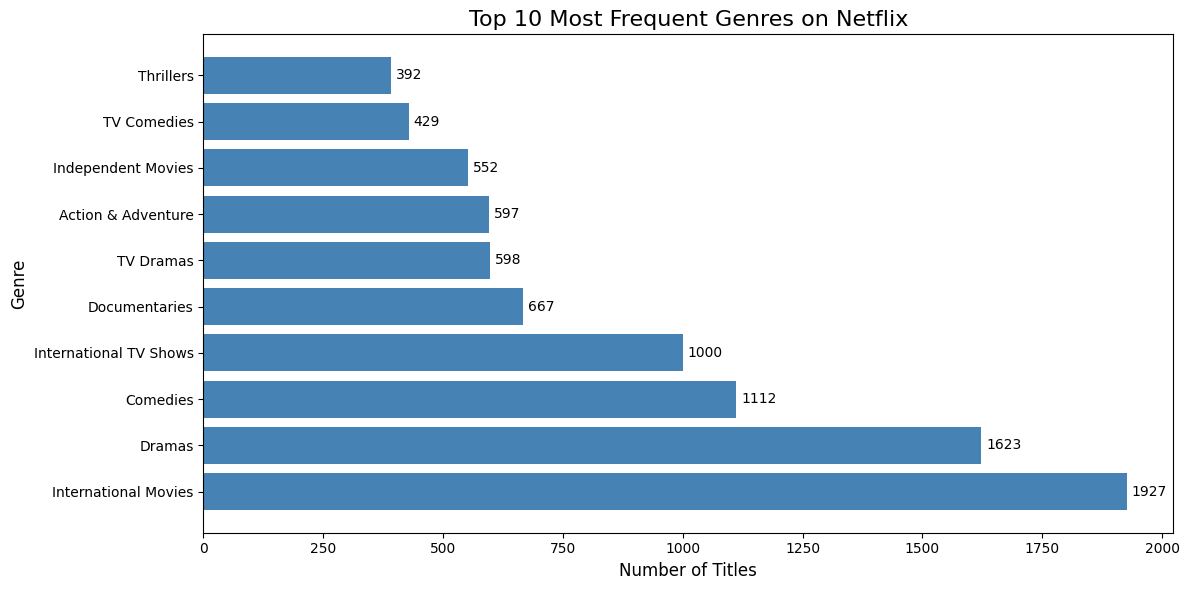

In [111]:
import matplotlib.pyplot as plt

# get top 10 most frequent genres from exploded dataframe
top10_genres = df_exploded['listed_in'].value_counts().head(10)

# create bar chart
plt.figure(figsize=(12, 6))
plt.barh(top10_genres.index, top10_genres.values, color='steelblue')

# add labels and title
plt.title('Top 10 Most Frequent Genres on Netflix', fontsize=16)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# add value labels on each bar
for i, v in enumerate(top10_genres.values):
    plt.text(v + 10, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Business Insight — Top 10 Genres on Netflix

The data shows a heavy concentration in the International Movies category
with 1927 titles. This suggests that Netflix prioritizes global content
over local content, making it accessible and appealing to subscribers
from every country in the world.

In [114]:
from google.colab import files
df_master.to_csv('netflix_cleaned.csv', index=False)
